<a href="https://colab.research.google.com/github/SachinKumar-IT/AI-ML-Learning/blob/main/rf_Regressor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [11]:
df=load_diabetes(as_frame=True).frame

In [12]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [13]:
X=df.drop("target", axis=1)
y=df["target"]

In [14]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [19]:
#Decision Tree
model=DecisionTreeRegressor(max_depth=5, min_samples_split=10)
model.fit(X_train, y_train)

y_pred_test=model.predict(X_test)
y_pred_train=model.predict(X_train)

print("Training Accuracy:", r2_score(y_train, y_pred_train)*100, "%")
print("Testing Accuracy:", r2_score(y_test, y_pred_test)*100, "%")

print("MSE Training:", mean_squared_error(y_train, y_pred_train))
print("MSE testing:", mean_squared_error(y_test, y_pred_test))

Training Accuracy: 66.75529897609293 %
Testing Accuracy: 29.730245536393163 %
MSE Training: 2043.9779145441712
MSE testing: 3793.3776094670643


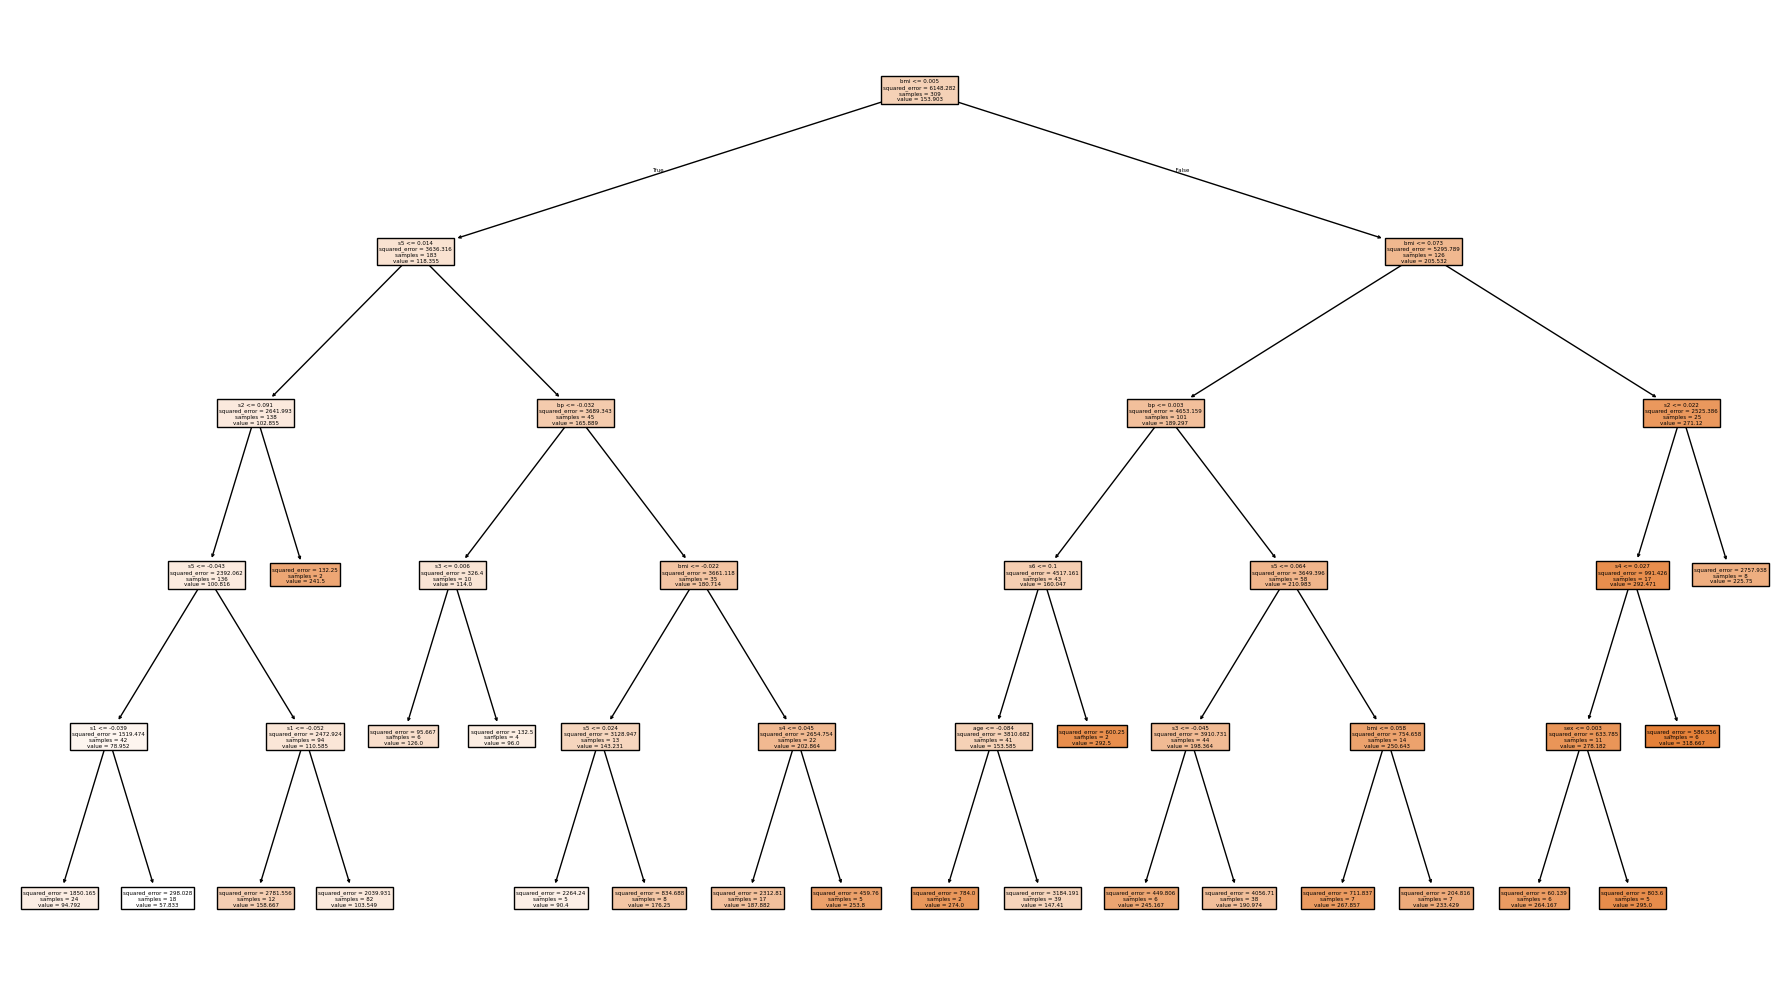

In [20]:
#Plotting Tree
from sklearn.tree import plot_tree
plt.figure(figsize=(18,10))

plot_tree(
    model,
    feature_names=X.columns,
    filled=True
)

plt.tight_layout()

In [22]:
# Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

rf= RandomForestRegressor(
    n_estimators=501,
    max_depth=5,
    min_samples_split=10,
    oob_score=True
)

rf.fit(X_train, y_train)

y_pred=rf.predict(X_test)

print("Testing Accuracy:", r2_score(y_test, y_pred)*100, "%")
print("OOB Score:", rf.oob_score_ *100, "%")

Testing Accuracy: 48.59883546233825 %
OOB Score: 44.863646975832 %
